
# 03_02 Group data with clustering algorithms

In this notebook, you will use K-Means clustering to find structure in the classic Iris dataset.


## Load the Iris dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix

df = pd.read_csv("C:/data/GitHub/BZIA_VM/DS/sk-learn_2026/data/penguins_clean.csv")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [8]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

## Prepare numeric features for clustering

In [21]:
# 2. Identify categorical and numeric columns
categorical= df[['species','island', 'sex', 'year']]
numeric= df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]


## Scale the features

In [22]:
categorical_encoded = pd.get_dummies(categorical, drop_first=False)
categorical_encoded.head()

,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,2007,True,False,False,False,False,True,False,True
1,2007,True,False,False,False,False,True,True,False
2,2007,True,False,False,False,False,True,True,False
3,2007,True,False,False,False,False,True,True,False
4,2007,True,False,False,False,False,True,False,True


In [24]:
scaler = StandardScaler()
scaled = scaler.fit_transform(numeric)

numeric_scaled = pd.DataFrame(scaled, columns=numeric.columns)
numeric_scaled.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


## Fit a K-Means clustering model

In [25]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto')
kmeans.fit(scaled)

cluster_labels = kmeans.labels_


C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## Compare clusters to true species labels

In [26]:
df["cluster"] = cluster_labels

crosstab = pd.crosstab(df["cluster"], df["species"])
crosstab


species,Adelie,Chinstrap,Gentoo
cluster,,,
0,124,5,0
1,0,0,119
2,22,63,0


In [27]:
pd.crosstab(df["cluster"], df["species"], margins=True)

species,Adelie,Chinstrap,Gentoo,All
cluster,,,,
0,124,5,0,129
1,0,0,119,119
2,22,63,0,85
All,146,68,119,333


In [28]:
pd.crosstab(df["cluster"], df["species"], normalize="index")

species,Adelie,Chinstrap,Gentoo
cluster,,,
0,0.961240,0.038760,0.0
1,0.000000,0.000000,1.0
2,0.258824,0.741176,0.0


In [29]:
pd.crosstab(df["cluster"], df["species"], normalize="columns")

species,Adelie,Chinstrap,Gentoo
cluster,,,
0,0.849315,0.073529,0.0
1,0.000000,0.000000,1.0
2,0.150685,0.926471,0.0


In [30]:
pd.crosstab(df["cluster"], df["species"], dropna=False)

species,Adelie,Chinstrap,Gentoo
cluster,,,
0,124,5,0
1,0,0,119
2,22,63,0


## Visualize clusters in feature space

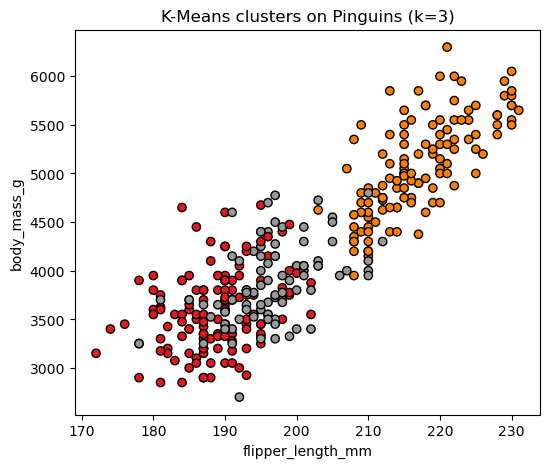

In [31]:

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    df['flipper_length_mm'],
    df['body_mass_g'],
    c=df["cluster"],
    cmap=plt.cm.Set1,
    edgecolor="k"
)
plt.xlabel('flipper_length_mm')
plt.ylabel('body_mass_g')
plt.title("K-Means clusters on Pinguins (k=3)")
plt.show()


## Choose the number of clusters using the "Elbow Method"

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

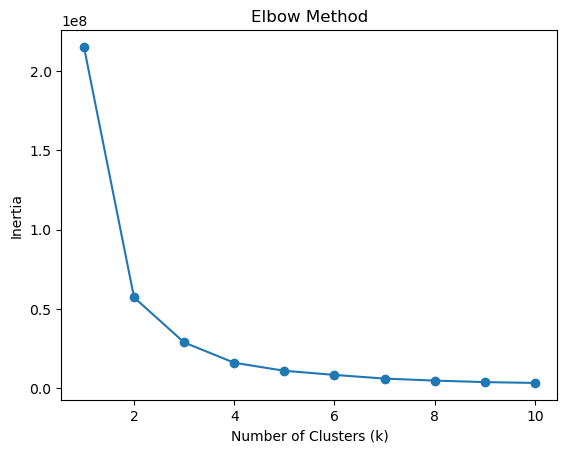

In [32]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()